In [2]:
# Importing the necessary libararies
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
cleaned_customer_transaction_data = pd.read_csv(r"C:\Users\User\Downloads\Fraudulent-Transaction_Detection_For_FinLora_Company\Finlora_Dataset\artifacts\Cleaned_Data.csv")

In [4]:
sns.set_theme(
	style="whitegrid",
	context="notebook",
	font_scale=1.1,
	palette="Spectral"
)

Distribution of Fraud and Transaction Channels

The charts above provide an initial understanding of the dataset and are important for the exploratory data analysis (EDA) stage. The fraud distribution chart is used to examine the balance between fraudulent and legitimate transactions. This is particularly important for fraud detection because an imbalanced target variable can cause a machine learning model to favour the majority class and perform poorly when identifying fraudulent transactions. Understanding the level of class imbalance helps determine whether techniques such as class weighting, resampling, or appropriate evaluation metrics may be required.

The transaction channel distribution chart shows how transactions are distributed across different channels, such as mobile, online, ATM, or other available channels. Examining this distribution helps identify dominant or underrepresented transaction channels and provides an initial indication of whether the channel may be relevant to fraudulent behaviour. These observations can also guide subsequent feature analysis and model development.

In [6]:
cleaned_customer_transaction_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

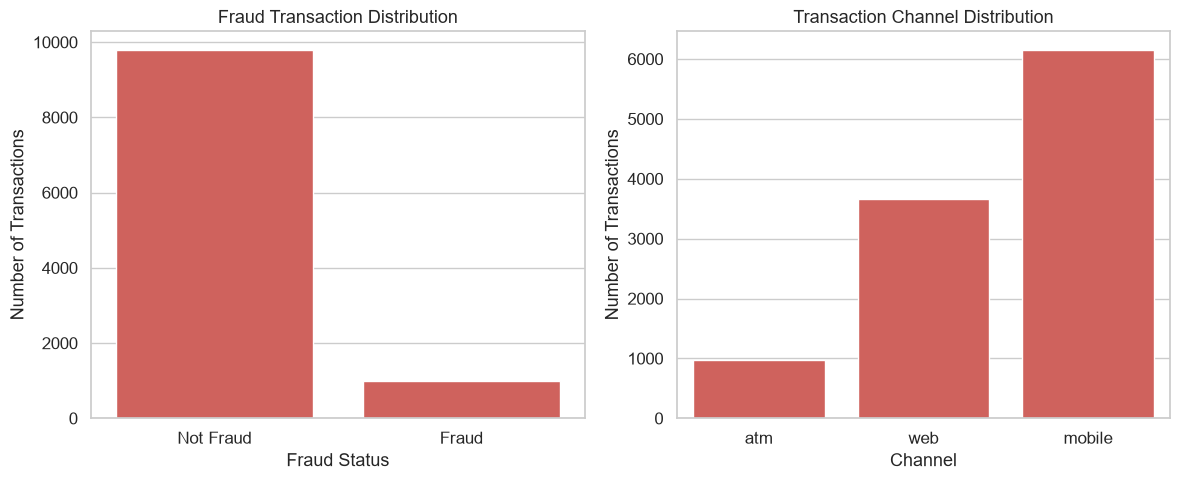

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud distribution
sns.countplot(data=cleaned_customer_transaction_data, x='is_fraud', ax=axes[0])
axes[0].set_title('Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

# Channel distribution
sns.countplot(data=cleaned_customer_transaction_data, x='channel', ax=axes[1])
axes[1].set_title('Transaction Channel Distribution')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

IP Country and KYC Tier Analysis

The charts provide an overview of the distribution of transactions across IP countries and KYC tiers, while also examining their relationship with fraudulent transactions. The IP country distribution helps identify the countries from which transactions are predominantly initiated and highlights countries that may be underrepresented in the dataset. Similarly, the KYC tier distribution shows how transactions are distributed across different levels of customer verification, providing an understanding of the composition of the customer base.

The IP country versus fraud chart compares fraudulent and legitimate transactions across countries. This is useful for identifying whether fraudulent transactions are concentrated within particular geographic locations, which may indicate potential geographic patterns that could be relevant to fraud detection. However, differences in the total number of transactions across countries should be considered when interpreting the results.

The KYC tier versus fraud chart examines the distribution of fraudulent and legitimate transactions across different KYC verification levels. This analysis can help determine whether fraud occurrence varies across customer verification tiers and whether KYC status may provide useful predictive information for the fraud detection model.

Overall, these visualisations help identify potential patterns and relationships between customer verification, transaction origin, and fraudulent behaviour, which can inform subsequent feature engineering and machine learning model development.

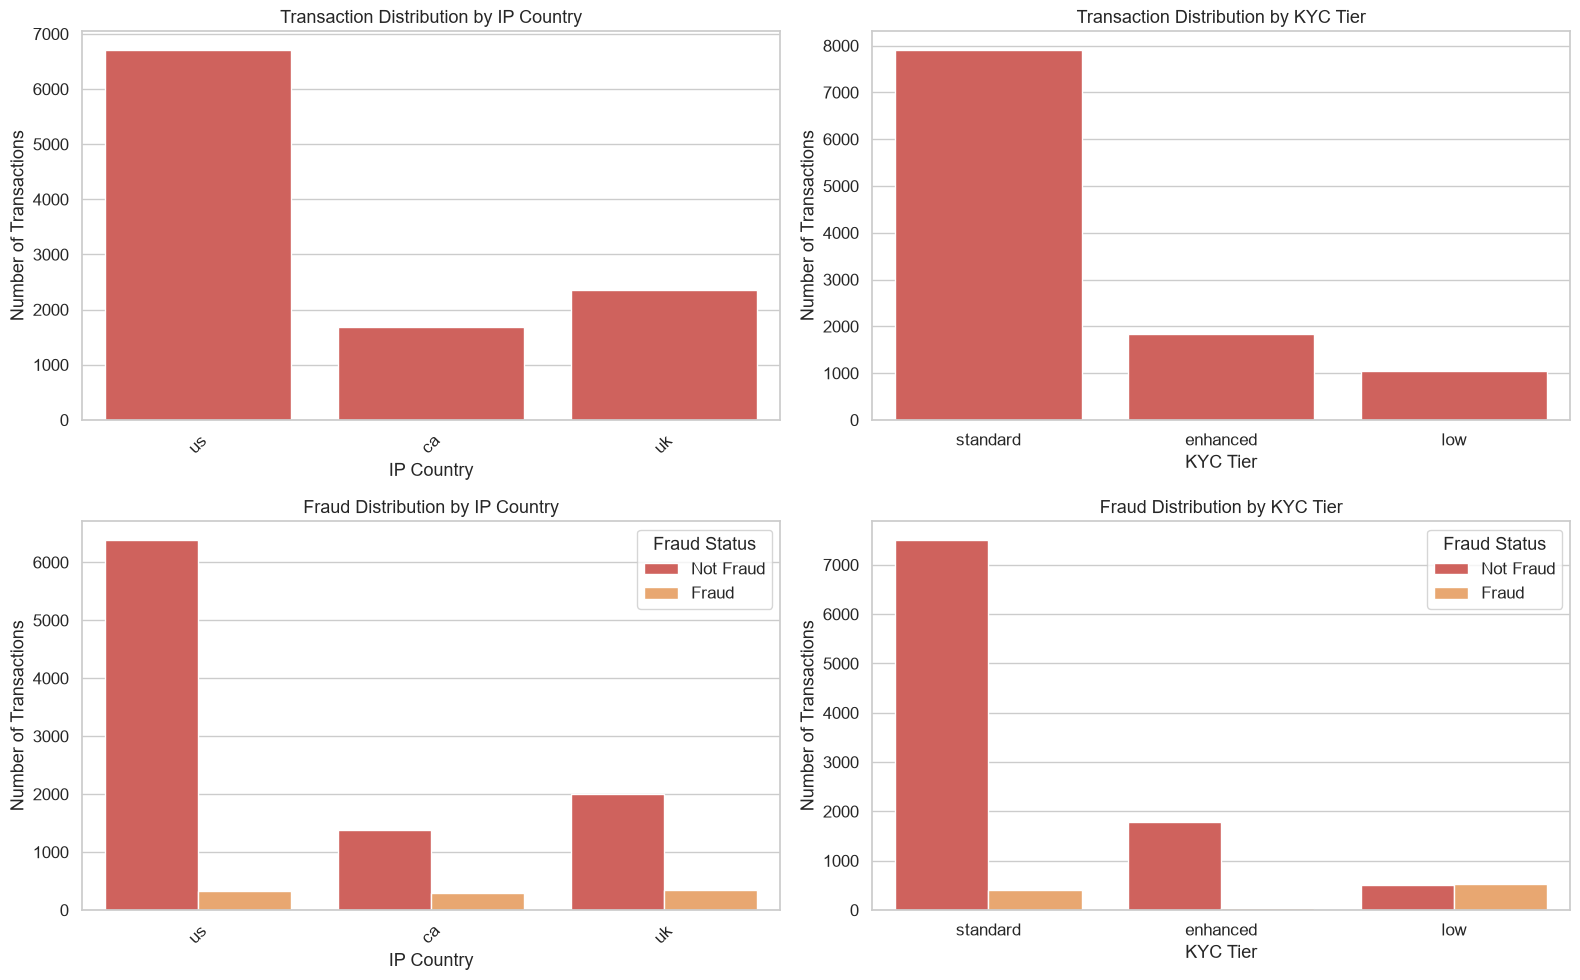

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. KYC Tier distribution
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions')

# 3. IP Country vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='ip_country',
    hue='is_fraud',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Fraud Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

# 4. KYC Tier vs Fraud
sns.countplot(
    data=cleaned_customer_transaction_data,
    x='kyc_tier',
    hue='is_fraud',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()



Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

The visualisations show how fraudulent transaction behaviour varies across location mismatch, KYC verification level, and transaction channel. The location mismatch analysis indicates a substantial difference in fraud risk depending on whether a transaction occurs in an expected location. Transactions where location_mismatch = False, meaning the transaction location is consistent with the user's expected or previously observed location, have a relatively low fraud rate of approximately 3-5%. In contrast, transactions where location_mismatch = True, indicating an unexpected or unfamiliar transaction location, have a considerably higher fraud rate of over 35%. Based on the observed rates, transactions with a location mismatch are approximately 7-9 times more likely to be fraudulent than transactions without a location mismatch. This suggests that location mismatch may be an important predictive feature for identifying potentially fraudulent transactions.

The analysis of KYC tier also shows differences in fraud risk across customer verification levels. The results indicate that customers with lower levels of KYC verification have higher fraud rates, while customers with enhanced verification have the lowest observed fraud risk. This suggests that the level of customer verification may provide useful information for distinguishing between legitimate and potentially fraudulent transactions.

The transaction channel analysis provides two complementary perspectives. The fraud-rate chart measures the proportion of transactions that are fraudulent within each channel, while the fraud-count chart measures the actual number of fraudulent and non-fraudulent transactions. The results indicate that web transactions have a higher fraud rate than mobile transactions, suggesting that the web channel may present a relatively higher fraud risk. However, fraud counts should be interpreted alongside fraud rates because differences in the total number of transactions across channels can influence the absolute number of fraudulent transactions.

The transaction channel analysis provides two complementary perspectives. The fraud-rate chart measures the proportion of transactions that are fraudulent within each channel, while the fraud-count chart measures the actual number of fraudulent and non-fraudulent transactions. The results indicate that web transactions have a higher fraud rate than mobile transactions, suggesting that the web channel may present a relatively higher fraud risk. However, fraud counts should be interpreted alongside fraud rates because differences in the total number of transactions across channels can influence the absolute number of fraudulent transactions.

Overall, these findings indicate that location mismatch, KYC verification level, and transaction channel may contain meaningful signals for fraud detection. These variables should therefore be considered during feature engineering and model development, while their predictive importance should ultimately be validated using statistical analysis and machine learning model evaluation.

C:\Users\User\AppData\Local\Temp\ipykernel_38468\3603564920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_38468\3603564920.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_38468\3603564920.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


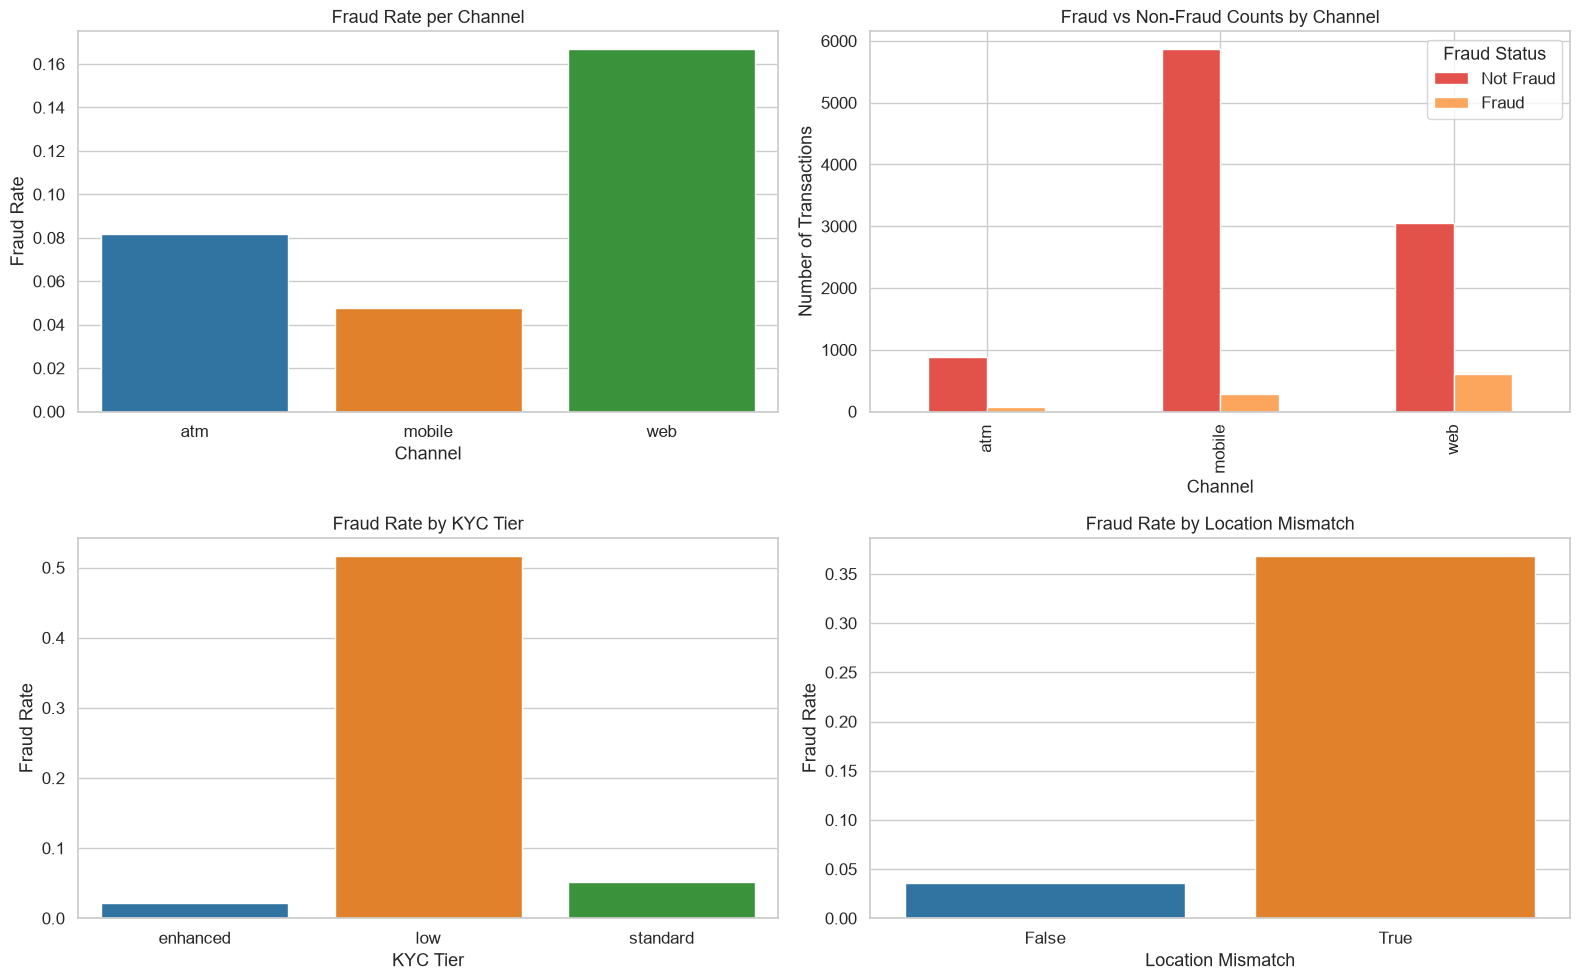

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud rate per channel
channel_fraud_rate = cleaned_customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()

sns.barplot(
    data=channel_fraud_rate,
    x='channel',
    y='is_fraud',
    ax=axes[0, 0],
    palette='tab10'
)

axes[0, 0].set_title('Fraud Rate per Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate')

# 2. Fraud vs Non-Fraud counts per channel
channel_counts = (
    cleaned_customer_transaction_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

channel_counts = channel_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
)

channel_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Fraud vs Non-Fraud Counts by Channel')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend(title='Fraud Status')


# 3. Fraud rate per KYC tier
kyc_fraud_rate = cleaned_customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud',
    ax=axes[1, 0],
    palette='tab10'
)

axes[1, 0].set_title('Fraud Rate by KYC Tier')
axes[1, 0].set_xlabel('KYC Tier')
axes[1, 0].set_ylabel('Fraud Rate')

# 4. Fraud rate per location mismatch
location_fraud_rate = (
    cleaned_customer_transaction_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=location_fraud_rate,
    x='location_mismatch',
    y='is_fraud',
    ax=axes[1, 1],
    palette='tab10'
)

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()


Transaction Velocity and Fraud Risk

The charts examine the relationship between transaction velocity and the likelihood of a transaction being fraudulent over both 1-hour and 24-hour periods. The results show a strong relationship between unusually high transaction frequency and fraudulent activity in the dataset.

For 1-hour transaction velocity, accounts making only one or two transactions within an hour have a very low fraud rate, representing relatively normal transaction behaviour. However, a substantial increase occurs around the third transaction, where the fraud rate rises sharply to above 80%. The fraud rate remains particularly high between approximately 3 and 5 transactions per hour, reaching around 70-80%. This pattern suggests that rapid bursts of transactions may be an important indicator of compromised accounts or automated fraudulent activity. Although the fraud rate begins to decline after five transactions and reaches approximately 45% around eight transactions per hour, it remains considerably higher than the baseline.

A similar pattern can be observed for 24-hour transaction velocity. Accounts making between 0 and 3 transactions per day have an extremely low observed fraud rate. However, the fraud rate increases substantially as transaction frequency rises, reaching approximately 75% around five transactions per day. Between approximately 5 and 8 transactions, the fraud rate remains relatively high at around 70-80%, despite a slight decline around eight transactions. The rate then increases again, approaching 100% at around 10 transactions per day in the observed data.

Overall, the results suggest that transaction velocity is an important behavioural signal for fraud detection. Higher transaction frequency, particularly when transactions occur in rapid bursts, is strongly associated with fraudulent activity in this dataset. These velocity-based features (txn_velocity_1h and txn_velocity_24h) may therefore provide valuable predictive information for the machine learning models. However, the observed rates should be interpreted as dataset-specific patterns rather than universal fraud thresholds, and their importance should be validated during model training and evaluation.

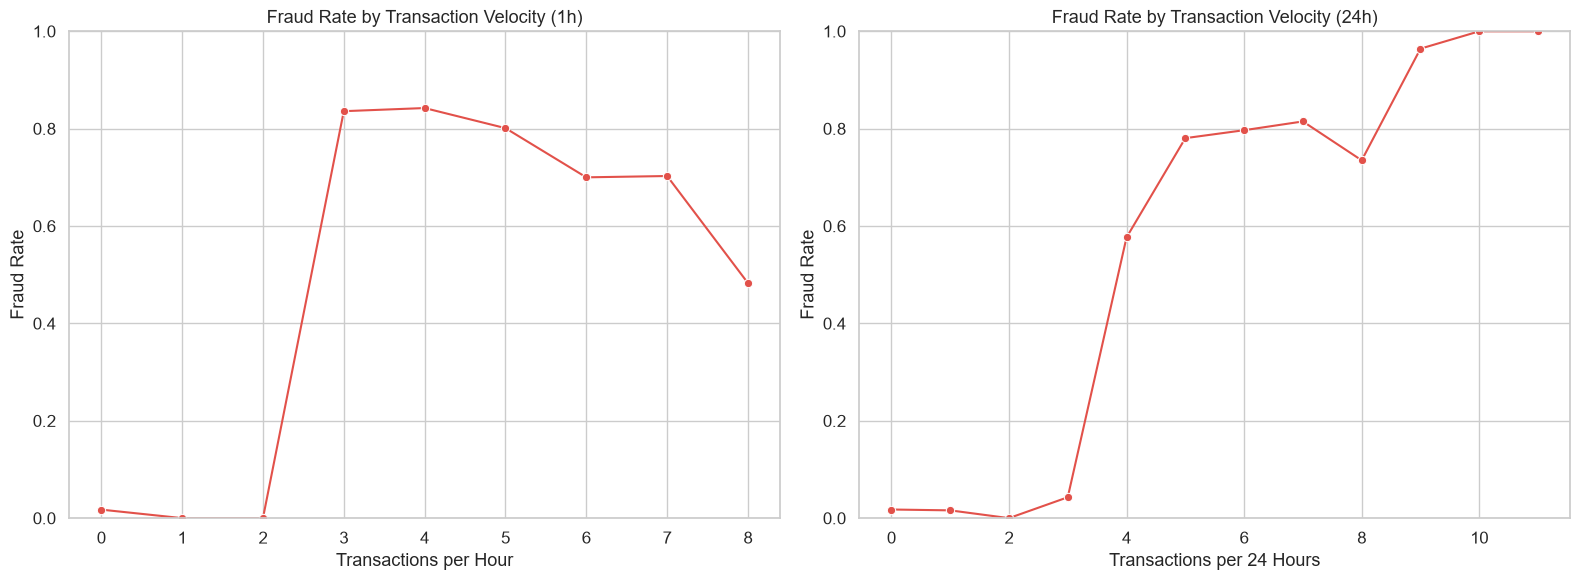

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Fraud rate by transaction velocity (1 hour)
txn_velocity_1h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_1h,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Fraud Rate by Transaction Velocity (1h)')
axes[0].set_xlabel('Transactions per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)


# 2. Fraud rate by transaction velocity (24 hours)
txn_velocity_24h = (
    cleaned_customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=txn_velocity_24h,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Fraud Rate by Transaction Velocity (24h)')
axes[1].set_xlabel('Transactions per 24 Hours')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_38468\3279599087.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


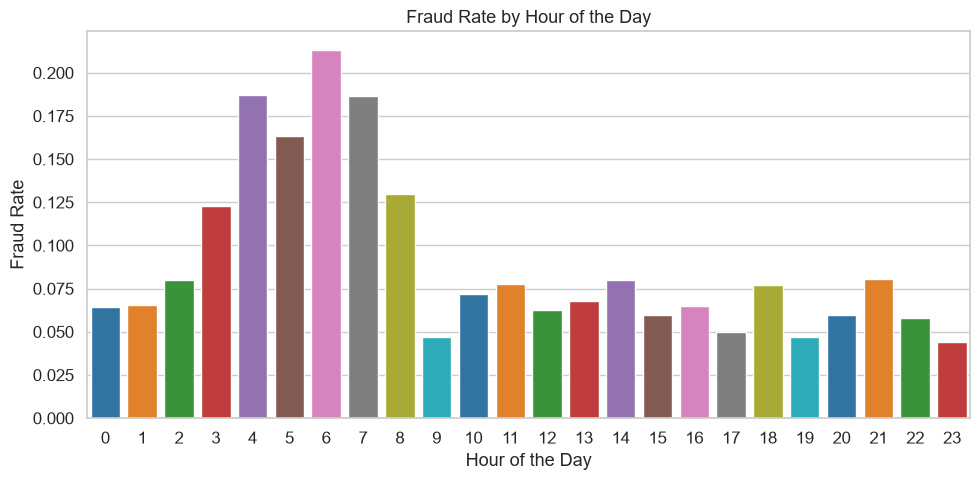

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_customer_transaction_data['timestamp'] = pd.to_datetime(cleaned_customer_transaction_data['timestamp'])

# Extract time-based features
cleaned_customer_transaction_data['hour'] = cleaned_customer_transaction_data['timestamp'].dt.hour
cleaned_customer_transaction_data['day_of_week'] = cleaned_customer_transaction_data['timestamp'].dt.dayofweek
cleaned_customer_transaction_data['is_weekend'] = (cleaned_customer_transaction_data['day_of_week'] >= 5).astype(int)
cleaned_customer_transaction_data['month'] = cleaned_customer_transaction_data['timestamp'].dt.month

# Fraud rate by hour
fraud_rate_by_hour = (
    cleaned_customer_transaction_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_hour,
    x='hour',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_38468\1036720228.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


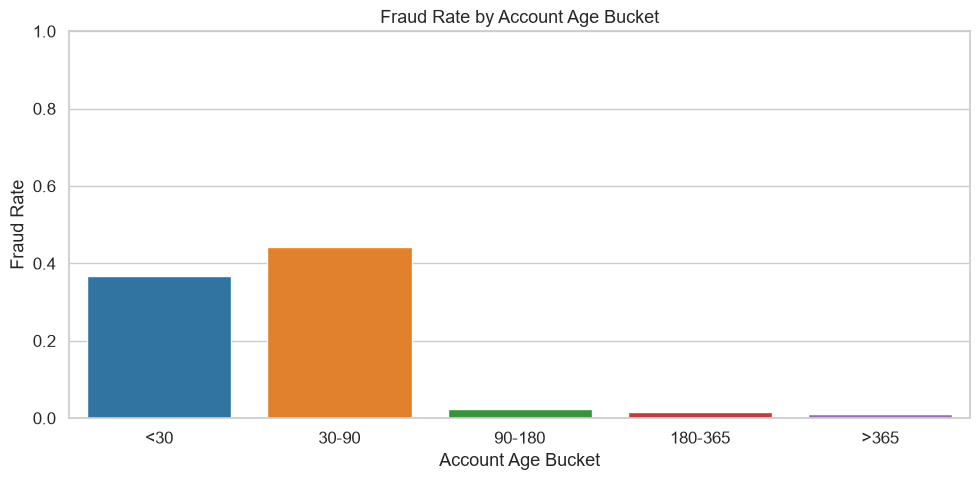

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# Create account age buckets
cleaned_customer_transaction_data['account_age_bucket'] = pd.cut(
    cleaned_customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30', '30-90', '90-180', '180-365', '>365']
)

# Calculate fraud rate by account age bucket
fraud_rate_by_account_age = (
    cleaned_customer_transaction_data.groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_account_age,
    x='account_age_bucket',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0, 1)
plt.title('Fraud Rate by Account Age Bucket')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_38468\3853554491.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_38468\3853554491.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_38468\3853554491.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


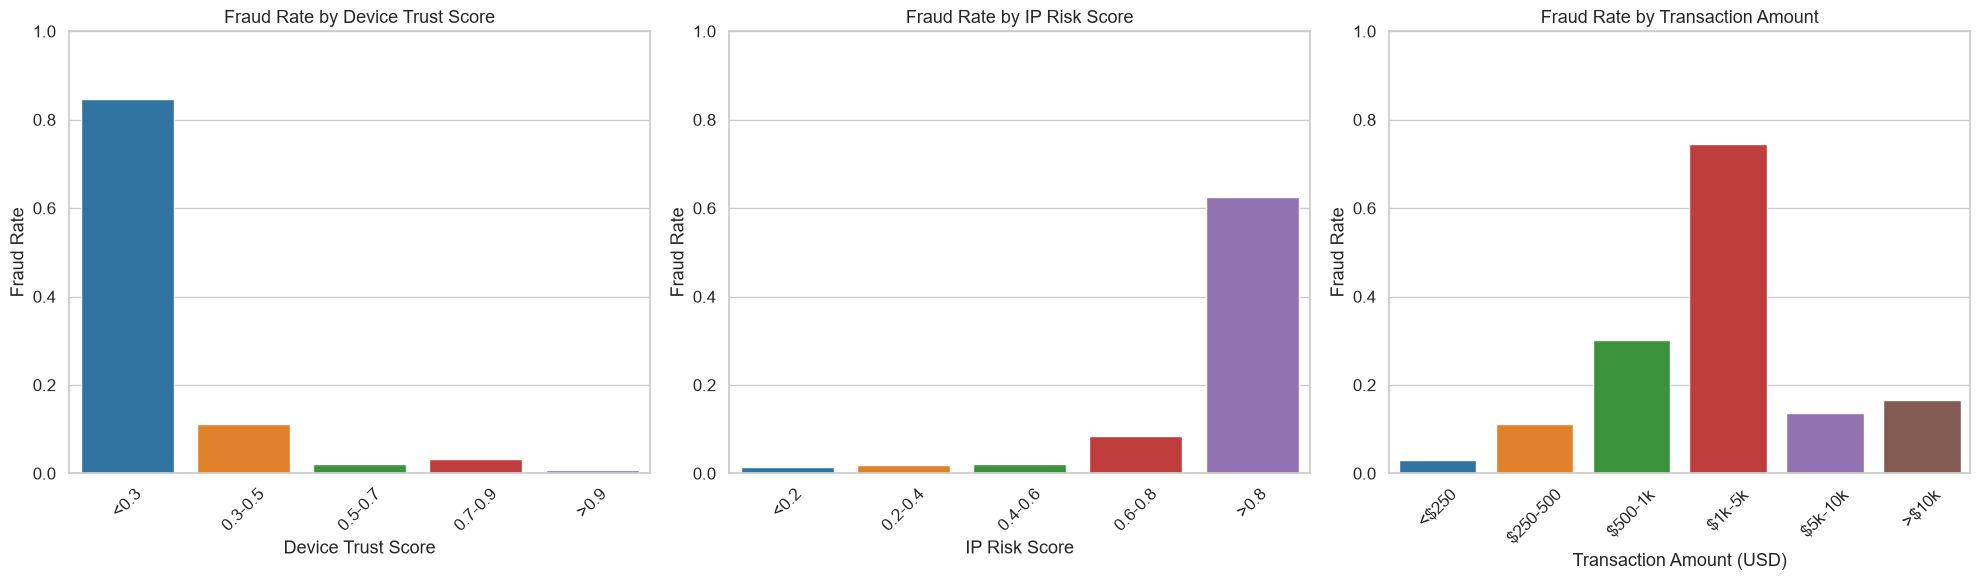

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fraud Rate by Device Trust Score

cleaned_customer_transaction_data['device_trust_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)

fraud_rate_by_device_trust_score = (
    cleaned_customer_transaction_data.groupby(
        'device_trust_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].tick_params(axis='x', rotation=45)

# 2. Fraud Rate by IP Risk Score

cleaned_customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
)

fraud_rate_by_ip_risk_score = (
    cleaned_customer_transaction_data.groupby(
        'ip_risk_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette='tab10'
)

axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].tick_params(axis='x', rotation=45)

# 3. Fraud Rate by Transaction Amount

cleaned_customer_transaction_data['amount_usd_bucket'] = pd.cut(
    cleaned_customer_transaction_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, 20000],
    labels=[
        '<$250',
        '$250-500',
        '$500-1k',
        '$1k-5k',
        '$5k-10k',
        '>$10k'
    ],
    include_lowest=True
)

fraud_rate_by_amount_usd = (
    cleaned_customer_transaction_data.groupby(
        'amount_usd_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette='tab10'
)

axes[2].set_xlabel('Transaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0, 1)
axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].tick_params(axis='x', rotation=45)

# Final layout

plt.tight_layout()
plt.show()

In [17]:

cleaned_customer_transaction_data.shape

(10780, 35)

In [18]:
cleaned_customer_transaction_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'hour', 'day_of_week', 'is_weekend', 'month', 'account_age_bucket',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket'],
      dtype='object')

In [19]:
cleaned_customer_transaction_data.to_csv(r'..Finlora_Dataset/artifacts/EDA_Data.csv', index=False)

OSError: Cannot save file into a non-existent directory: '..Finlora_Dataset\artifacts'

In [20]:
import os

# 1. Define the directory path and ensure it exists
output_dir = r'..\Finlora_Dataset\artifacts'
os.makedirs(output_dir, exist_ok=True)

# 2. Save the dataframe to CSV
cleaned_customer_transaction_data.to_csv(
    os.path.join(output_dir, 'EDA_Data.csv'), 
    index=False
)